# ELM corpus: analyzing powers

Unlike KDUQ, CHUQ and Test, the ELM corpus is not defined by a table of EXFOR
subentries. It is a query -- every EXFOR analyzing power data set for elastic nucleon scattering on the same near-spherical targets between 10 and 200 MeV -- followed by a
sequence of human judgements: entries excluded as duplicates or as lacking
uncertainties, parses repaired by naming the right uncertainty columns, and individual
points corrected for apparent transcription errors.

Those judgements are the corpus. They are recorded in `nn_corpora.elm` with the reasons
given in the original ELM notebooks, and applied here.

Analyzing powers are dimensionless and bounded by one, so the uncertainty floor below which a reported error is treated as absent is looser here than for cross sections.

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np

from nn_corpora import elm, elm_curate, munge, plotting, serialize, spec

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## Targets

The corpus is restricted to near-spherical nuclei, where a spherical optical model is
defensible. The cut is on the quadrupole deformation, and drops $^{42}$Ca and $^{44}$Ca.

In [2]:
targets = spec.elm_targets()
print(f"{len(targets)} targets below beta2 = {spec.MAX_BETA2}:")
print(", ".join(f"{A if A else 'nat'}{__import__('periodictable').elements[Z].symbol}"
                for A, Z in sorted(targets, key=lambda t: (t[1], t[0]))))

21 targets below beta2 = 0.16:
40Ca, 48Ca, 64Ni, 86Sr, 88Sr, 90Zr, 92Zr, 94Zr, 96Zr, 92Mo, 94Mo, 116Sn, 118Sn, 120Sn, 122Sn, 124Sn, 138Ba, 144Sm, 148Sm, 206Pb, 208Pb


## Query

In [3]:
nn = elm_curate.query_elastic(
    projectile=spec.PROJECTILES["neutron"], quantities=("Ay",),
    targets=targets, einc_range=spec.ELM_ELASTIC_EINC_RANGE,
    min_num_pts=spec.ELM_MIN_NUM_PTS,
)
pp = elm_curate.query_elastic(
    projectile=spec.PROJECTILES["proton"], quantities=("Ay",),
    targets=targets, einc_range=spec.ELM_ELASTIC_EINC_RANGE,
    min_num_pts=spec.ELM_MIN_NUM_PTS,
)
print(f"(n,n): {sum(len(m.data['Ay'].entries) for m in nn.values())} entries")
print(f"(p,p): {sum(len(m.data['Ay'].entries) for m in pp.values())} entries")

(n,n): 7 entries
(p,p): 72 entries


## Repair and exclude

The analyzing power sector needed far less intervention than the cross sections: the
original notebooks recorded no parse repairs here and only a handful of exclusions,
all of data sets duplicated or lacking uncertainties.

In [4]:
result = elm_curate.ElmSectorResult(sector="elastic_ay")
elm_curate.repair_failed_parses(nn, ("Ay",), result)
elm_curate.repair_failed_parses(pp, ("Ay",), result)

# 48Ca: E0249 and O0032 are deliberately kept for Ay, though excluded from the
# cross sections, where they duplicate E0166.
elm_curate.exclude_entries(pp, "Ay", {"E0773": "duplicate", "E0904": "no uncertainties"},
                           result)
print("\n".join(sorted(set(result.repaired + result.excluded))) or "no intervention needed")

Ay D0289 via ('ERR-S', 'ERR-DIG')
Ay E0773: duplicate
Ay E0904: no uncertainties
Ay O0208 via ('ERR-2',)
Ay O0287 via ('DATA-ERR',)
Ay O0328 via ('ERR-1', 'ERR-DIG')


## Munge and serialize

In [5]:
elm_curate.finalize(nn, "elastic_ay", "neutron", result)
elm_curate.finalize(pp, "elastic_ay", "proton", result)
print(result.summary())

elm/elastic_ay
  targets                0
  measurements           96
  data points            2757
  excluded
    Ay E0773: duplicate
    Ay E0904: no uncertainties
    Ay E0904: no uncertainties
  repaired
    Ay O0208 via ('ERR-2',)
    Ay O0208 via ('ERR-2',)
    Ay O0328 via ('ERR-1', 'ERR-DIG')
    Ay D0289 via ('ERR-S', 'ERR-DIG')
    Ay O0208 via ('ERR-2',)
    Ay O0287 via ('DATA-ERR',)
  dropped
    E1677022: one or more uncertainties below the Ay floor 0.001
    E1677023: one or more uncertainties below the Ay floor 0.001
    E1677024: one or more uncertainties below the Ay floor 0.001
    E1677025: one or more uncertainties below the Ay floor 0.001
    E1677026: one or more uncertainties below the Ay floor 0.001
    E1677027: one or more uncertainties below the Ay floor 0.001
    O0351011: reported as a polarization cross section in barns/ster, not a dimensionless analyzing power
    F0930004: only 1 scattering angle(s); too sparse to constrain an optical potential
    F093

## Inspect

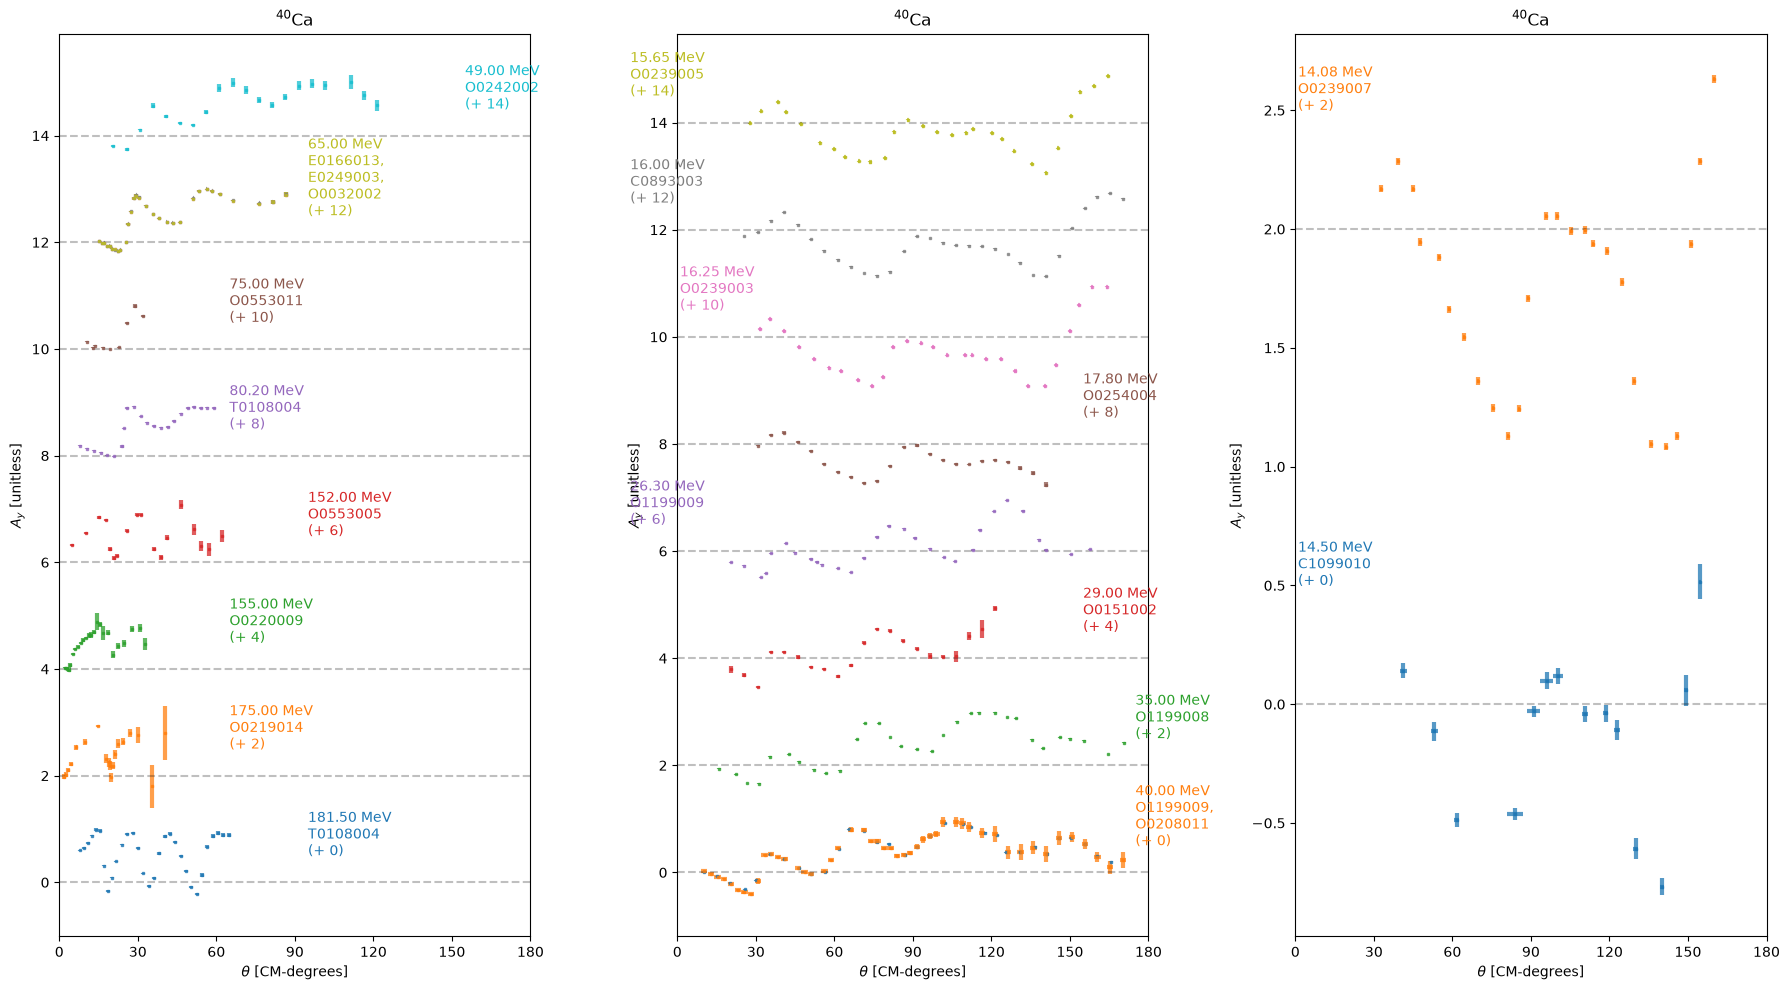

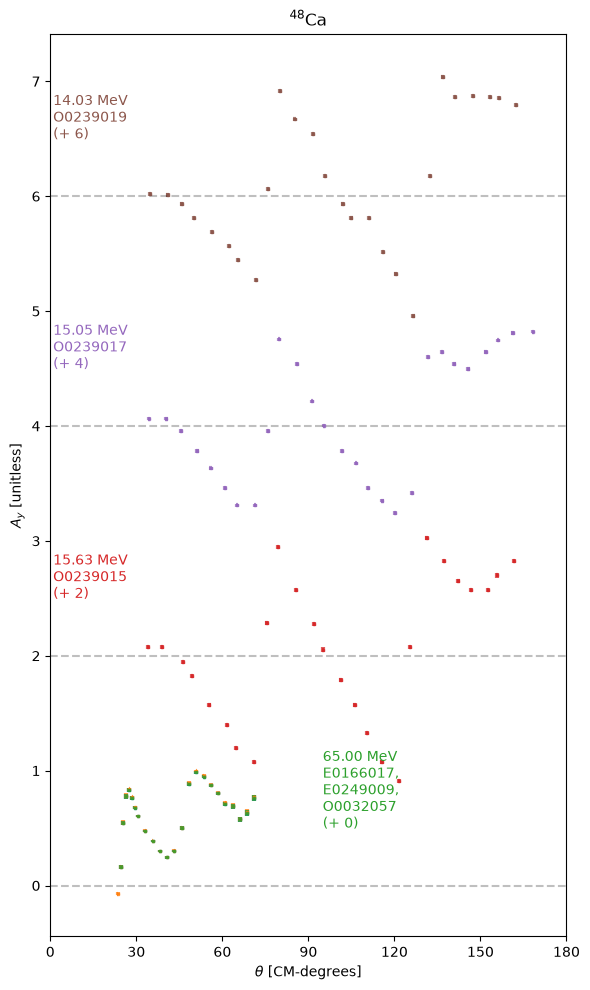

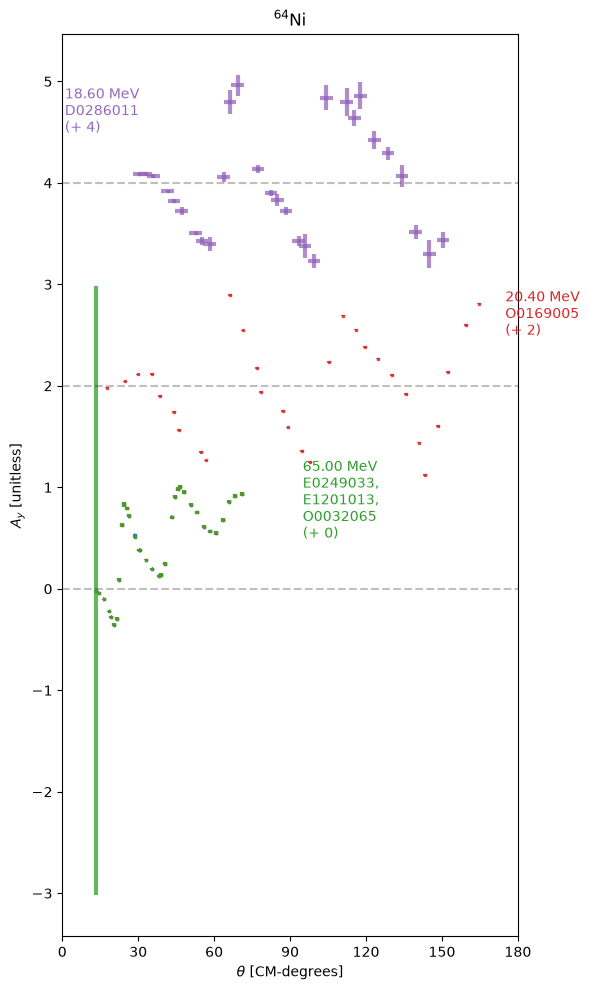

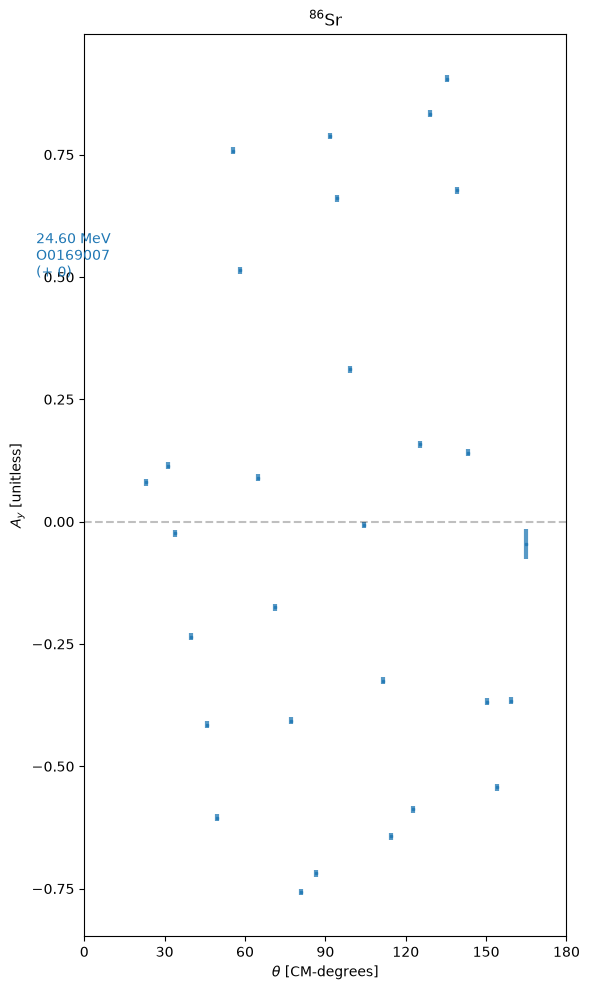

In [6]:
for target, multi in sorted(pp.items())[:4]:
    measurements = [m for e in multi.data["Ay"].entries.values() for m in e.measurements]
    if measurements:
        plotting.plot_angular(measurements, title=plotting._latex(
            f"{target[0] or 'nat'}{__import__('periodictable').elements[target[1]].symbol}"))
plt.show()

## Write

In [7]:
serialize.write_sector(result.records, corpus="elm", sector="elastic_ay",
                       bibtex=result.bibtex)
print(f"wrote {len(result.records)} measurements to data/elm/elastic_ay/")


wrote 96 measurements to data/elm/elastic_ay/
